# Abdelkrim el ayachi

ce document contine le code de traner un neural networ pour comprendre et classifier les images avec mes commentaires

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision.transforms as transforms
import torchvision.datasets as datasets

from sklearn import decomposition
from sklearn import manifold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

Ce bloc de code sert à fixer une graine (seed) pour toutes les bibliothèques utilisées afin de garantir la reproductibilité des expériences en apprentissage automatique. En fixant la seed pour random, NumPy et PyTorch (CPU et GPU), on s’assure que les opérations aléatoires (initialisation des poids, mélange des données, etc.) produisent toujours les mêmes résultats à chaque exécution.

In [3]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Ce code charge le dataset MNIST depuis la bibliothèque torchvision et le stocke localement dans le dossier spécifié par ROOT. Il utilise uniquement la partie d’entraînement du dataset afin d’analyser les données avant l’entraînement du modèle. Ensuite, il calcule la moyenne et l’écart-type des pixels des images en convertissant d’abord les valeurs en float puis en les normalisant par 255 pour ramener les valeurs dans l’intervalle [0,1].

In [4]:
ROOT = '.data'

train_data = datasets.MNIST(root=ROOT,
                            train=True,
                            download=True)

mean = train_data.data.float().mean() / 255
std = train_data.data.float().std() / 255

print(f'Calculated mean: {mean}')
print(f'Calculated std: {std}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


Calculated mean: 0.13066047430038452
Calculated std: 0.30810779333114624


Ce code définit deux pipelines de transformation des images pour l’entraînement et le test dans un modèle de vision par ordinateur. Le pipeline d’entraînement applique des augmentations de données afin d’améliorer la généralisation du modèle, notamment une légère rotation aléatoire des images et un recadrage aléatoire avec padding pour simuler des variations naturelles des données. Ensuite, les images sont converties en tenseurs et normalisées à l’aide de la moyenne et de l’écart-type calculés précédemment afin d’assurer une distribution stable des valeurs d’entrée. Le pipeline de test, quant à lui, n’applique aucune transformation aléatoire pour garantir des résultats déterministes et une évaluation fiable du modèle, il se limite donc à la conversion en tenseur et à la normalisation avec les mêmes statistiques.

In [5]:
train_transforms = transforms.Compose([
                            transforms.RandomRotation(5, fill=(0,)),
                            transforms.RandomCrop(28, padding=2),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=[mean], std=[std])
                                      ])

test_transforms = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[mean], std=[std])
                                     ])

télécharger données depuis MNIST dataset et le séparer en 2 (train data & test data)

In [6]:
train_data = datasets.MNIST(root=ROOT,
                            train=True,
                            download=True,
                            transform=train_transforms)

test_data = datasets.MNIST(root=ROOT,
                           train=False,
                           download=True,
                           transform=test_transforms)

séparer train data en 2 parties
- partie 1 (train data) : contient 90% de données
- partie 2 (validation data) : contient 10% de données

In [7]:
VALID_RATIO = 0.9

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = data.random_split(train_data,
                                           [n_train_examples, n_valid_examples])

- on utilise deep copy pour créer nouvelle dataset ( ancinneent on utilise random
- On remplace les transformers utilisés sur les données d’entraînement par ceux utilisés sur les données de validation et de test, afin d’obtenir une meilleure évaluation et des résultats plus robustes.

In [8]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

afficher la quantité de notre data en chaque partie (train, test, validation) & vérifier que la quantités est correcte on doit trouve

In [9]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 54000
Number of validation examples: 6000
Number of testing examples: 10000


Ce code crée les itérateurs de données (DataLoaders) utilisés pour alimenter le modèle pendant l’entraînement, la validation et le test. Il définit d’abord une taille de batch fixée à 64, ce qui signifie que les données seront traitées par paquets de 64 échantillons à la fois pour optimiser les performances et l’utilisation mémoire. Ensuite, le DataLoader d’entraînement est configuré avec un mélange aléatoire des données (shuffle=True) afin d’améliorer la généralisation du modèle en évitant l’apprentissage d’un ordre fixe. Les DataLoaders de validation et de test utilisent la même taille de batch mais sans mélange, afin de garantir des évaluations cohérentes et reproductibles des performances du modèle.

In [10]:
BATCH_SIZE = 64

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_data,
                                batch_size=BATCH_SIZE)

Cette fonction sert à visualiser l’effet d’un filtre de convolution appliqué à un ensemble d’images. Elle commence par regrouper les images dans un tenseur unique compatible avec PyTorch, puis convertit le filtre fourni en tenseur 4D afin de pouvoir l’utiliser avec une convolution 2D. Le nombre d’images est ensuite récupéré pour organiser l’affichage. Le filtre est appliqué à toutes les images afin de produire une version transformée mettant en évidence certaines caractéristiques visuelles comme les contours ou les textures. Enfin, la fonction utilise Matplotlib pour afficher, pour chaque image, l’originale et sa version filtrée côte à côte, ce qui permet de comparer directement l’effet du filtre.

In [11]:
def plot_filter(images, filter):

    images = images = torch.cat([i.unsqueeze(0) for i in images],
                                dim=0).cpu()
    filter = torch.FloatTensor(filter).unsqueeze(0).unsqueeze(0).cpu()

    n_images = images.shape[0]

    filtered_images = F.conv2d(images, filter)

    fig = plt.figure(figsize=(20, 5))

    for i in range(n_images):

        ax = fig.add_subplot(2, n_images, i+1)
        ax.imshow(images[i].squeeze(0), cmap='bone')
        ax.set_title('Original')
        ax.axis('off')

        image = filtered_images[i].squeeze(0)

        ax = fig.add_subplot(2, n_images, n_images+i+1)
        ax.imshow(image, cmap='bone')
        ax.set_title('Filtered')
        ax.axis('off')

Ce code permet d’extraire un petit échantillon d’images depuis le dataset de test afin de les utiliser pour des visualisations ou des tests rapides. Il commence par définir le nombre d’images à récupérer (`N_IMAGES = 5`). Ensuite, il parcourt les `N_IMAGES` premiers éléments de `test_data`, qui contient des paires *(image, label)*, et récupère uniquement les images en ignorant les labels. Le résultat est une liste contenant les cinq premières images du dataset de test, prête à être utilisée pour des opérations comme l’affichage ou l’application de filtres.

In [12]:
N_IMAGES = 5

images = [image for image, label in [test_data[i] for i in range(N_IMAGES)]]

Ce code définit un filtre de convolution horizontal utilisé pour détecter les variations d’intensité dans une image, en particulier les contours horizontaux. Il correspond à un noyau de type Sobel qui met en évidence les changements verticaux de pixels, ce qui permet d’identifier les bords horizontaux dans une image. Ensuite, ce filtre est appliqué aux images sélectionnées à l’aide de la fonction `plot_filter`, qui affiche pour chaque image l’originale et la version filtrée afin de visualiser l’effet du filtre sur les structures de l’image.

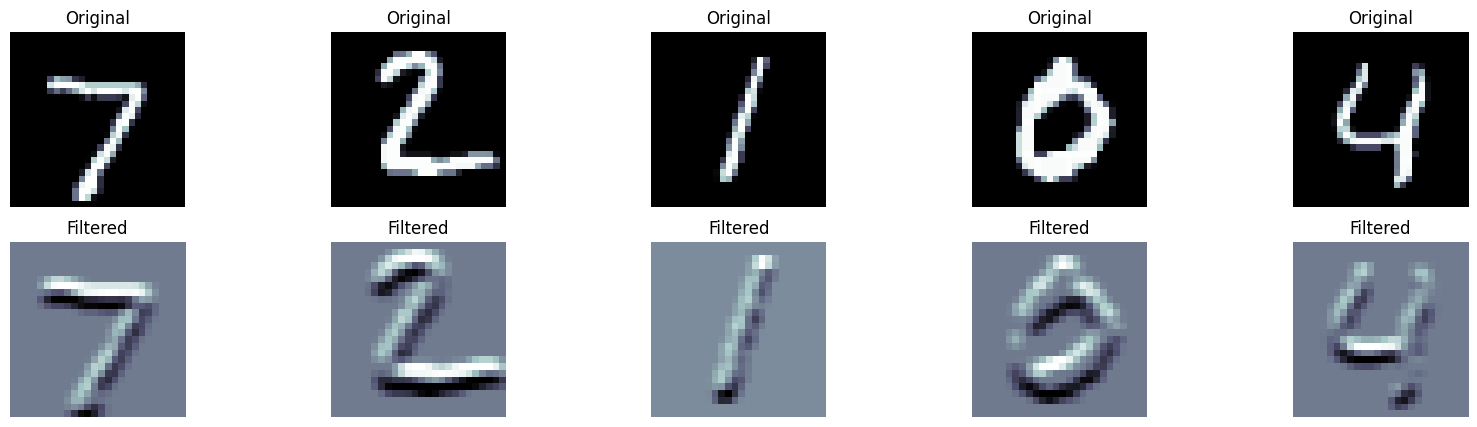

In [13]:
horizontal_filter = [[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]]

plot_filter(images, horizontal_filter)

Ce code définit un filtre de convolution de type Sobel utilisé pour détecter les contours horizontaux dans une image en mettant en évidence les variations d’intensité verticales. Ce noyau accentue les transitions entre les zones claires et sombres selon l’axe vertical, ce qui permet de faire ressortir les bords horizontaux. Ensuite, ce filtre est appliqué à un ensemble d’images à l’aide de la fonction `plot_filter`, qui affiche pour chaque image la version originale ainsi que la version filtrée afin de visualiser l’effet du filtre sur les caractéristiques structurelles de l’image.

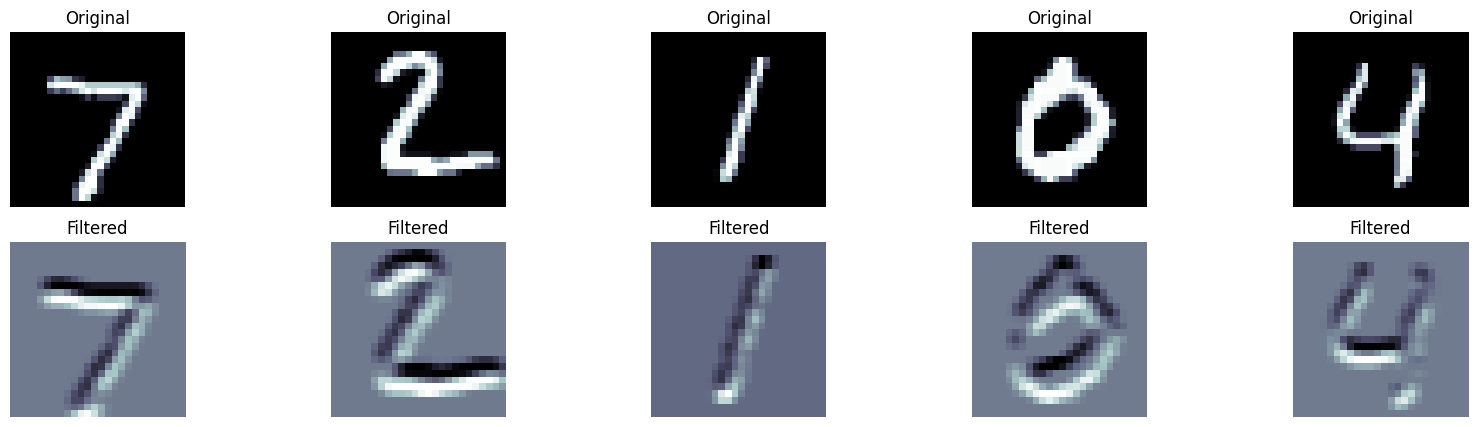

In [14]:
horizontal_filter = [[ 1,  2,  1],
                     [ 0,  0,  0],
                     [-1, -2, -1]]

plot_filter(images, horizontal_filter)

Ce code définit un filtre de convolution de type Sobel utilisé pour détecter les contours verticaux dans une image. Ce noyau met en évidence les variations d’intensité selon l’axe horizontal, ce qui permet de faire ressortir les bords verticaux. Ensuite, la fonction `plot_filter` applique ce filtre à un ensemble d’images et affiche pour chacune d’elles l’image originale ainsi que l’image filtrée, afin de visualiser l’effet du filtre sur les structures verticales présentes dans l’image.

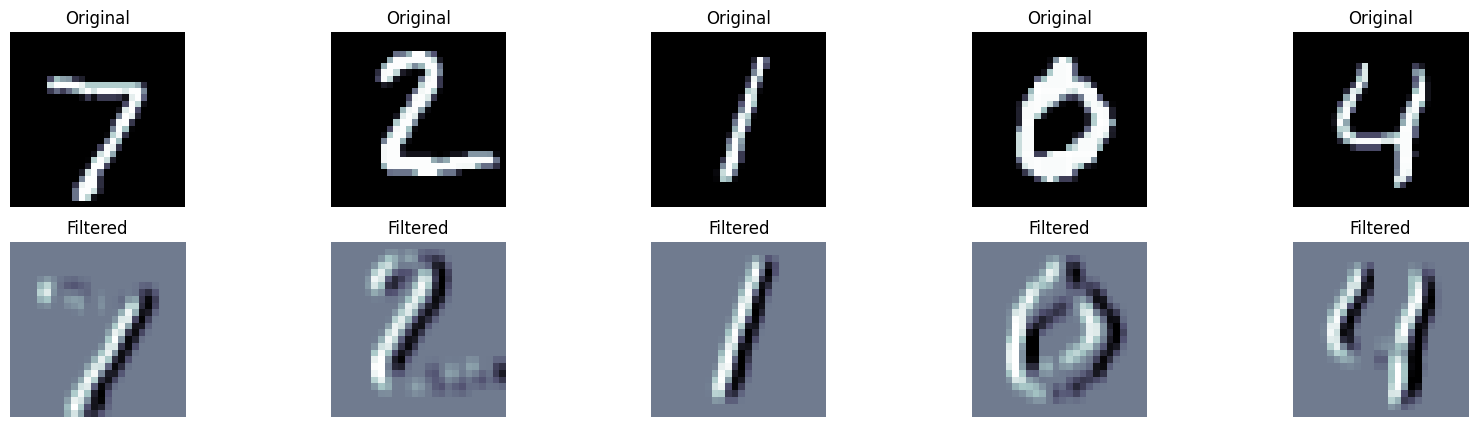

In [15]:
vertical_filter = [[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]]

plot_filter(images, vertical_filter)

Ce code définit un filtre de convolution de type Sobel utilisé pour détecter les contours verticaux dans une image en mettant en évidence les variations d’intensité selon l’axe horizontal. Ce noyau accentue les transitions entre zones claires et sombres de gauche à droite, ce qui permet de faire ressortir les bords verticaux. Ensuite, la fonction `plot_filter` applique ce filtre à un ensemble d’images et affiche pour chacune d’elles l’image originale ainsi que la version filtrée afin de visualiser l’effet du filtre sur les structures verticales présentes dans l’image.

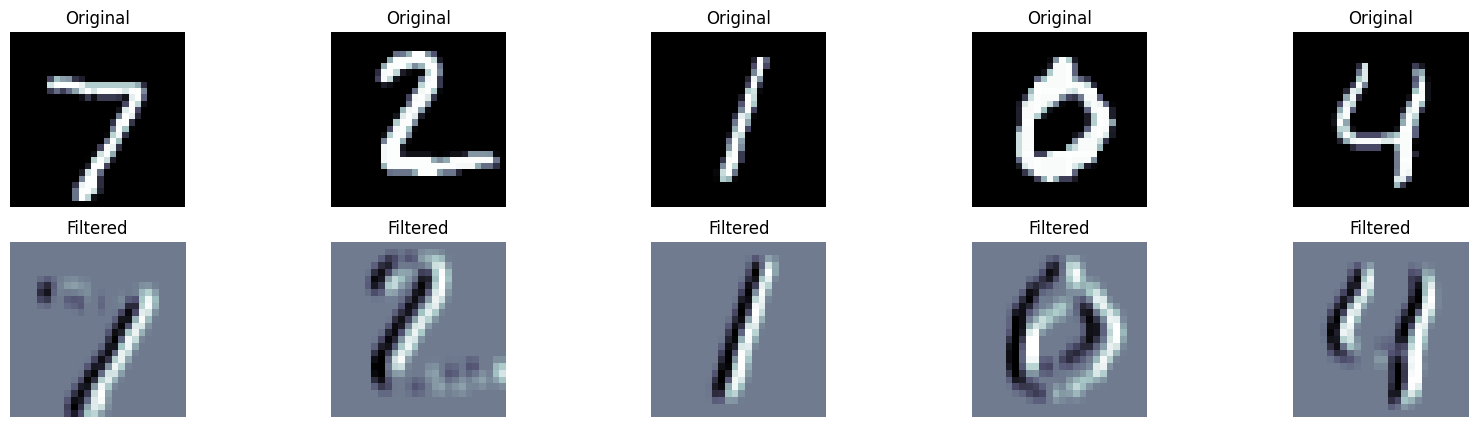

In [16]:
vertical_filter = [[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]]

plot_filter(images, vertical_filter)

Ce code définit un filtre de convolution destiné à détecter les contours diagonaux dans une image. Ce noyau met en évidence les variations d’intensité le long d’une direction diagonale, en accentuant les transitions entre les zones sombres et claires qui suivent cet axe. Ensuite, la fonction `plot_filter` applique ce filtre à un ensemble d’images et affiche pour chacune d’elles l’image originale ainsi que la version filtrée, afin de visualiser l’effet du filtre sur les structures diagonales présentes dans l’image.

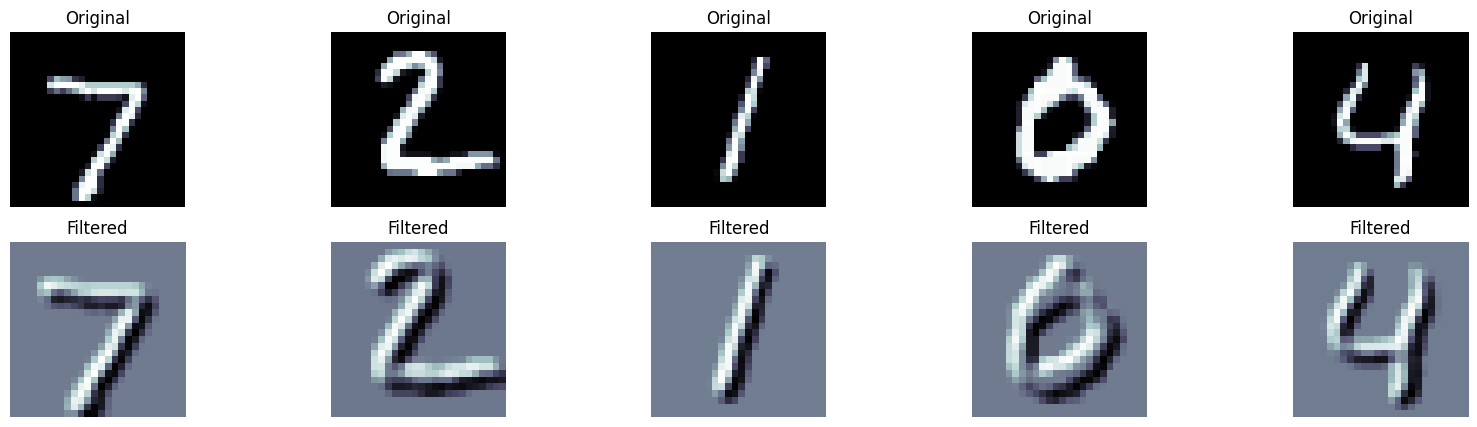

In [17]:
diagonal_filter = [[-2, -1, 0],
                   [-1,  0, 1],
                   [ 0,  1, 2]]

plot_filter(images, diagonal_filter)

Cette fonction applique une opération de **subsampling (pooling)** sur un ensemble d’images et compare le résultat à l’image originale. Elle convertit d’abord la liste d’images en tenseur, puis choisit dynamiquement le type de pooling (`max` ou `average`) selon `pool_type`. Le pooling est appliqué avec une taille de fenêtre définie par `pool_size`, ce qui réduit la résolution des images tout en conservant les informations principales. Enfin, elle affiche côte à côte les images originales et leurs versions sous-échantillonnées pour visualiser l’effet de la réduction de dimension.

In [18]:
def plot_subsample(images, pool_type, pool_size):

    images = torch.cat([i.unsqueeze(0) for i in images], dim=0).cpu()

    if pool_type.lower() == 'max':
        pool = F.max_pool2d
    elif pool_type.lower() in ['mean', 'avg']:
        pool = F.avg_pool2d
    else:
        raise ValueError(f'pool_type must be either max or mean, got: {pool_type}')

    n_images = images.shape[0]

    pooled_images = pool(images, kernel_size=pool_size)

    fig = plt.figure(figsize=(20, 5))

    for i in range(n_images):

        ax = fig.add_subplot(2, n_images, i+1)
        ax.imshow(images[i].squeeze(0), cmap='bone')
        ax.set_title('Original')
        ax.axis('off')

        image = pooled_images[i].squeeze(0)

        ax = fig.add_subplot(2, n_images, n_images+i+1)
        ax.imshow(image, cmap='bone')
        ax.set_title('Subsampled')
        ax.axis('off')

Ce code applique un **max pooling** de taille 2×2 sur les images via la fonction `plot_subsample`, puis affiche les images originales et leurs versions sous-échantillonnées pour comparer l’effet de la réduction de résolution.

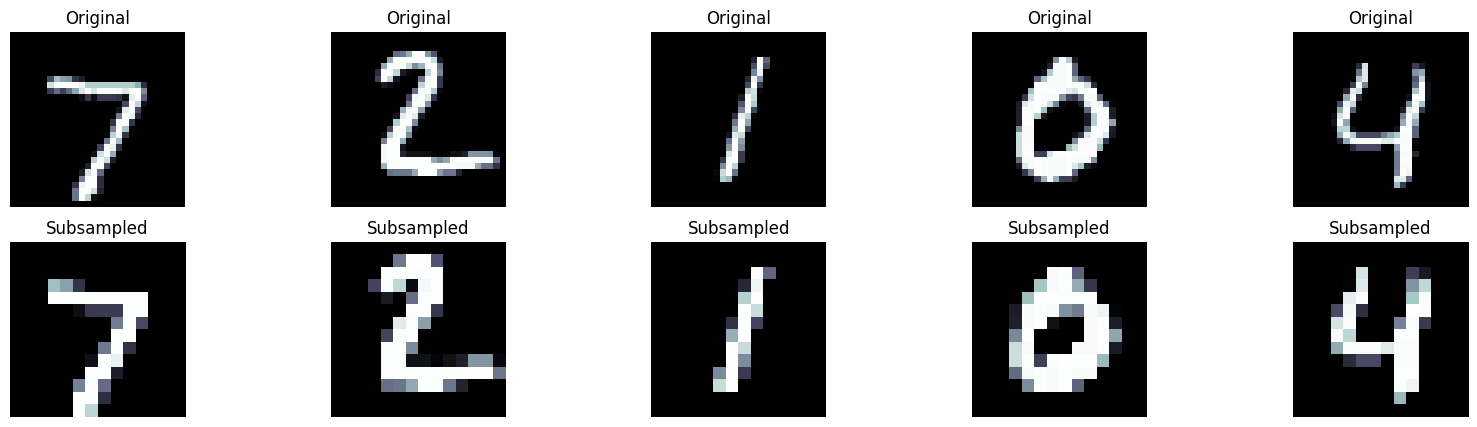

In [19]:
plot_subsample(images, 'max', 2)

Ce code applique un **max pooling** de taille 3×3 sur les images via la fonction `plot_subsample`. Il réduit la résolution des images en conservant uniquement les valeurs maximales dans chaque région, puis affiche les images originales et leurs versions sous-échantillonnées pour visualiser l’effet de cette opération.

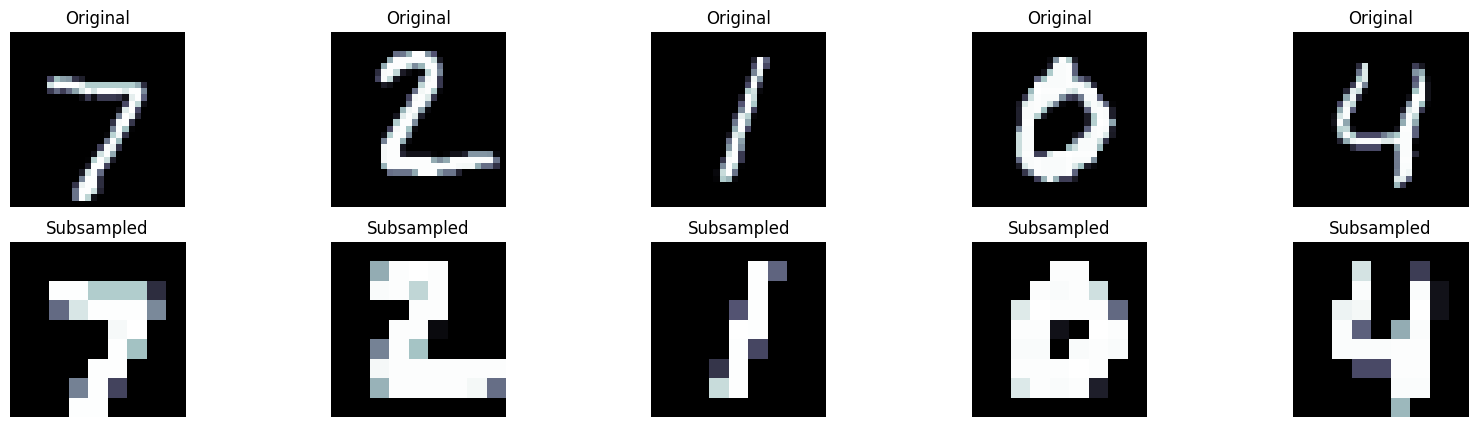

In [20]:
plot_subsample(images, 'max', 3)

Ce code applique un **average pooling** de taille 2×2 sur les images via la fonction `plot_subsample`. Il remplace chaque région locale par la moyenne de ses pixels, ce qui réduit la résolution tout en conservant une version plus lissée de l’image. Ensuite, il affiche les images originales et leurs versions sous-échantillonnées pour comparer l’effet du filtrage.

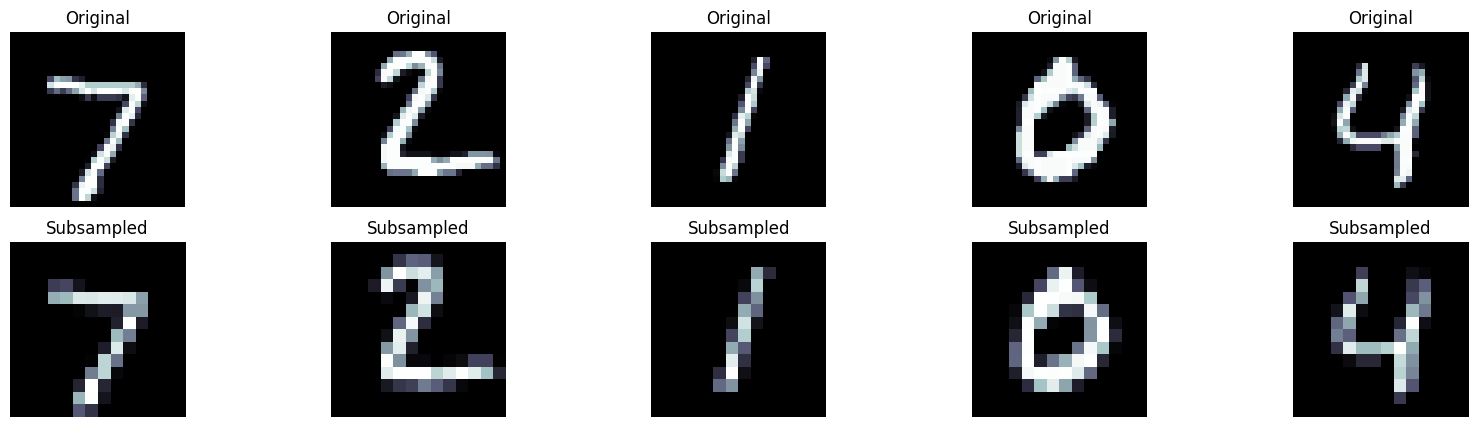

In [21]:
plot_subsample(images, 'avg', 2)

Ce code applique un **average pooling** de taille 3×3 sur les images via la fonction `plot_subsample`. Chaque bloc de pixels est remplacé par sa moyenne, ce qui réduit la résolution tout en lissant l’image et en conservant les informations globales. Ensuite, il affiche les images originales et leurs versions sous-échantillonnées pour visualiser l’effet de cette opération.

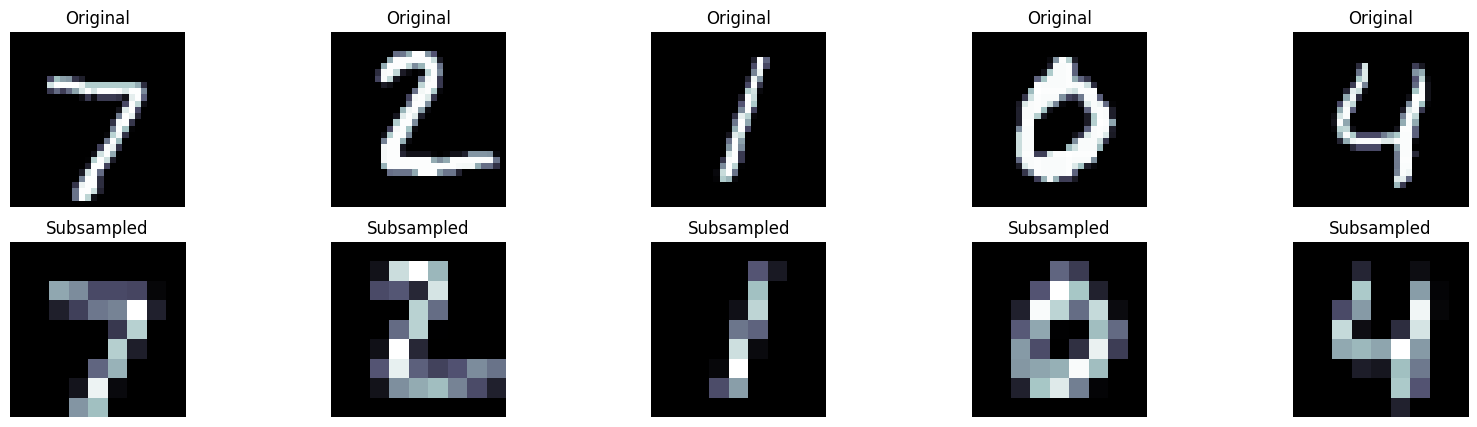

In [22]:
plot_subsample(images, 'avg', 3)

Il s’agit d’une implémentation du réseau de neurones convolutif LeNet en PyTorch pour la classification d’images.

Le modèle est composé de deux parties principales : un extracteur de caractéristiques et un classificateur. L’extracteur de caractéristiques contient deux couches convolutionnelles. La première couche convolutionnelle prend une image en niveau de gris (un seul canal) et génère 6 cartes de caractéristiques à l’aide d’un noyau de convolution de taille 5×5. La deuxième couche convolutionnelle prend ces 6 cartes de caractéristiques en entrée et en produit 16, également avec un noyau 5×5. Après chaque couche convolutionnelle, une opération de max pooling est appliquée afin de réduire la dimension spatiale, et une activation ReLU est utilisée pour introduire de la non-linéarité.

Après les couches convolutionnelles, les cartes de caractéristiques sont aplaties en un vecteur unidimensionnel. Ce vecteur est ensuite passé à travers trois couches entièrement connectées, qui réduisent progressivement la dimension de 256 à 120, puis à 84, et enfin au nombre de classes de sortie. La sortie finale représente les scores de classification (logits) pour chaque classe.

En plus de la sortie finale, le modèle retourne également la représentation intermédiaire aplatie avant les couches fully connected. Cette représentation peut être utilisée pour la visualisation ou l’analyse des caractéristiques apprises.


In [23]:
class LeNet(nn.Module):
    def __init__(self, output_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=6,
                               kernel_size=5)

        self.conv2 = nn.Conv2d(in_channels=6,
                               out_channels=16,
                               kernel_size=5)

        self.fc_1 = nn.Linear(16 * 4 * 4, 120)
        self.fc_2 = nn.Linear(120, 84)
        self.fc_3 = nn.Linear(84, output_dim)

    def forward(self, x):

        # x = [batch size, 1, 28, 28]

        x = self.conv1(x)

        # x = [batch size, 6, 24, 24]

        x = F.max_pool2d(x, kernel_size=2)

        # x = [batch size, 6, 12, 12]

        x = F.relu(x)

        x = self.conv2(x)

        # x = [batch size, 16, 8, 8]

        x = F.max_pool2d(x, kernel_size=2)

        # x = [batch size, 16, 4, 4]

        x = F.relu(x)

        x = x.view(x.shape[0], -1)

        # x = [batch size, 16*4*4 = 256]

        h = x

        x = self.fc_1(x)

        # x = [batch size, 120]

        x = F.relu(x)

        x = self.fc_2(x)

        # x = batch size, 84]

        x = F.relu(x)

        x = self.fc_3(x)

        # x = [batch size, output dim]

        return x, h

Ce code définit le nombre de classes de sortie du modèle à 10, ce qui correspond aux 10 chiffres du dataset MNIST (de 0 à 9). Ensuite, il crée une instance du modèle LeNet en lui passant cette valeur, ce qui configure la dernière couche du réseau pour produire 10 scores de classification, un pour chaque classe.

In [24]:
OUTPUT_DIM = 10

model = LeNet(OUTPUT_DIM)

Cette fonction permet de calculer le nombre total de paramètres entraînables dans un modèle PyTorch.

Elle parcourt tous les paramètres du modèle et ne garde que ceux qui nécessitent un gradient (`requires_grad=True`), c’est-à-dire ceux qui seront mis à jour pendant l’entraînement. Pour chacun de ces paramètres, elle récupère le nombre d’éléments qu’il contient, puis fait la somme de tous ces éléments afin d’obtenir le total.

Ensuite, le code affiche ce nombre sous forme lisible pour évaluer la complexité du modèle et avoir une idée de sa taille en termes de capacité d’apprentissage.

In [25]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 44,426 trainable parameters


Ce code définit l’optimiseur Adam de PyTorch pour entraîner le modèle. Il met à jour automatiquement les paramètres du réseau en fonction des gradients afin d’améliorer la vitesse et la stabilité de l’apprentissage.

In [26]:
optimizer = optim.Adam(model.parameters())

Ce code définit la fonction de perte utilisée pour entraîner le modèle dans PyTorch. `CrossEntropyLoss` est adaptée aux problèmes de classification multi-classes : elle compare les prédictions du modèle aux vraies étiquettes et mesure l’erreur afin de guider la mise à jour des poids pendant l’entraînement.

In [27]:
criterion = nn.CrossEntropyLoss()

Ce code définit le dispositif (device) sur lequel le modèle et les calculs seront exécutés dans PyTorch. Si un GPU compatible CUDA est disponible, il est utilisé pour accélérer les calculs, sinon le CPU est utilisé par défaut.

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Ce code déplace le modèle et la fonction de perte sur le dispositif sélectionné (GPU si disponible, sinon CPU) dans PyTorch. Cela permet d’assurer que les calculs sont effectués sur le même device pour éviter les erreurs et optimiser les performances, notamment en utilisant l’accélération GPU lorsque c’est possible.

In [29]:
model = model.to(device)
criterion = criterion.to(device)

Cette fonction calcule la **précision (accuracy)** d’un modèle de classification dans PyTorch.

Elle commence par récupérer la classe prédite pour chaque exemple en utilisant `argmax`, ce qui sélectionne la valeur la plus élevée dans les prédictions du modèle. Ensuite, elle compare ces prédictions avec les vraies étiquettes afin de compter le nombre de prédictions correctes. Enfin, elle divise ce nombre par le total d’exemples pour obtenir le taux de précision du modèle.

In [30]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

Cette fonction définit la boucle d’entraînement d’une époque pour un modèle de classification dans PyTorch.

Elle commence par initialiser les variables de suivi de la perte et de la précision pour l’époque. Le modèle est ensuite mis en mode entraînement avec `model.train()` afin d’activer le comportement spécifique du training (comme le dropout ou batch normalization).

Pour chaque batch de données provenant de l’itérateur, les entrées et labels sont transférés sur le device (CPU ou GPU). Les gradients sont remis à zéro avant chaque mise à jour pour éviter leur accumulation. Le modèle produit des prédictions à partir des entrées, puis la perte est calculée en comparant ces prédictions aux vraies étiquettes. La précision du batch est également calculée.

Ensuite, la rétropropagation est effectuée avec `loss.backward()`, et l’optimiseur met à jour les poids du modèle avec `optimizer.step()`. La perte et la précision sont accumulées pour calculer les moyennes sur toute l’époque.

Enfin, la fonction retourne la perte moyenne et la précision moyenne sur l’ensemble des batches.

In [31]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred, _ = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

Cette fonction définit la boucle d’évaluation d’un modèle de classification dans PyTorch.

Elle commence par initialiser les variables de suivi de la perte et de la précision. Le modèle est ensuite mis en mode évaluation avec `model.eval()`, ce qui désactive certains comportements spécifiques à l’entraînement comme le dropout. Ensuite, `torch.no_grad()` est utilisé pour désactiver le calcul des gradients, ce qui réduit l’utilisation mémoire et accélère les calculs.

Pour chaque batch de données, les entrées et les labels sont déplacés sur le device approprié. Le modèle génère des prédictions, puis la perte est calculée et la précision est mesurée en comparant les prédictions aux vraies étiquettes. Contrairement à l’entraînement, aucun backpropagation ni mise à jour des poids n’est effectué.

Enfin, la fonction retourne la perte moyenne et la précision moyenne sur l’ensemble des batches pour évaluer les performances du modèle.

In [32]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

Cette fonction calcule le **temps d’exécution d’une époque d’entraînement ou d’évaluation**.

Elle commence par calculer la durée totale en secondes en faisant la différence entre le temps de fin et le temps de début. Ensuite, elle convertit ce temps en minutes et secondes pour obtenir un format plus lisible. Enfin, elle retourne le temps écoulé sous forme de tuple contenant le nombre de minutes et de secondes.

In [33]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

Ce code définit la boucle principale d’entraînement du modèle sur plusieurs époques dans PyTorch.

Il commence par fixer le nombre d’époques à 20 et initialise la meilleure loss de validation à l’infini pour pouvoir sauvegarder le meilleur modèle. Ensuite, pour chaque époque, il mesure le temps d’exécution et lance la phase d’entraînement suivie de la phase d’évaluation sur les données de validation.

Après chaque époque, il compare la perte de validation actuelle avec la meilleure obtenue jusqu’à présent. Si le modèle s’améliore, ses poids sont sauvegardés. Enfin, il calcule le temps écoulé pour l’époque et affiche les métriques principales (loss et accuracy) pour l’entraînement et la validation afin de suivre l’évolution des performances du modèle.

In [34]:
EPOCHS = 20

best_valid_loss = float('inf')

for epoch in trange(EPOCHS, desc="Epochs"):

    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut2-model.pt')

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Training:   0%|          | 0/844 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 38s
	Train Loss: 0.419 | Train Acc: 86.43%
	 Val. Loss: 0.118 |  Val. Acc: 96.38%


Training:   0%|          | 0/844 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 19 | Epoch Time: 0m 33s
	Train Loss: 0.033 | Train Acc: 99.01%
	 Val. Loss: 0.036 |  Val. Acc: 98.99%


Training:   0%|          | 0/844 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 20 | Epoch Time: 0m 32s
	Train Loss: 0.033 | Train Acc: 98.95%
	 Val. Loss: 0.039 |  Val. Acc: 98.87%


Ce code charge le meilleur modèle sauvegardé pendant l’entraînement dans PyTorch en utilisant les poids stockés dans le fichier `'tut2-model.pt'`. Il restaure ainsi l’état du réseau correspondant à la meilleure performance sur les données de validation.

Ensuite, le modèle est évalué sur le jeu de test à l’aide de la fonction `evaluate`, afin de mesurer sa performance sur des données jamais vues pendant l’entraînement. Enfin, il affiche la perte de test et la précision du modèle pour donner une estimation finale de sa capacité de généralisation.

In [35]:
model.load_state_dict(torch.load('tut2-model.pt'))

test_loss, test_acc = evaluate(model, test_iterator, criterion, device)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 0.024 | Test Acc: 99.21%


Cette fonction sert à récupérer les **prédictions complètes d’un modèle** dans PyTorch sur un dataset donné.

Elle commence par mettre le modèle en mode évaluation avec `model.eval()` afin de désactiver les comportements spécifiques à l’entraînement. Ensuite, elle désactive le calcul des gradients avec `torch.no_grad()` pour améliorer les performances et réduire l’utilisation mémoire.

Pour chaque batch de données, les images sont envoyées sur le device approprié et passées dans le modèle pour obtenir les prédictions. Ces prédictions sont ensuite transformées en probabilités via `softmax`. Les images, labels et probabilités sont stockés sur le CPU pour être facilement manipulés après l’inférence.

Enfin, tous les batches sont concaténés pour reconstruire l’ensemble complet du dataset et la fonction retourne les images, les vraies étiquettes et les probabilités prédites par le modèle.


In [36]:
def get_predictions(model, iterator, device):

    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred, _ = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

Ce code récupère les images du test set, les vraies labels et les probabilités prédites par le modèle en appelant `get_predictions`, afin d’analyser ses performances.


In [37]:
images, labels, probs = get_predictions(model, test_iterator, device)

Ce code calcule les classes prédites par le modèle en sélectionnant, pour chaque exemple, l’indice de la probabilité la plus élevée dans `probs`. Cela correspond à la classe finale prédite pour chaque image.

In [38]:
pred_labels = torch.argmax(probs, 1)

Cette fonction calcule et affiche la matrice de confusion du modèle dans PyTorch en comparant les labels réels et les prédictions, afin de visualiser les erreurs de classification pour chaque classe.

In [39]:
def plot_confusion_matrix(labels, pred_labels):

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    cm = confusion_matrix(labels, pred_labels)
    cm = ConfusionMatrixDisplay(cm, display_labels=range(10))
    cm.plot(values_format='d', cmap='Blues', ax=ax)

Ce code affiche la matrice de confusion du modèle dans PyTorch en comparant les vraies étiquettes avec les prédictions afin de visualiser les performances et les erreurs de classification pour chaque classe.

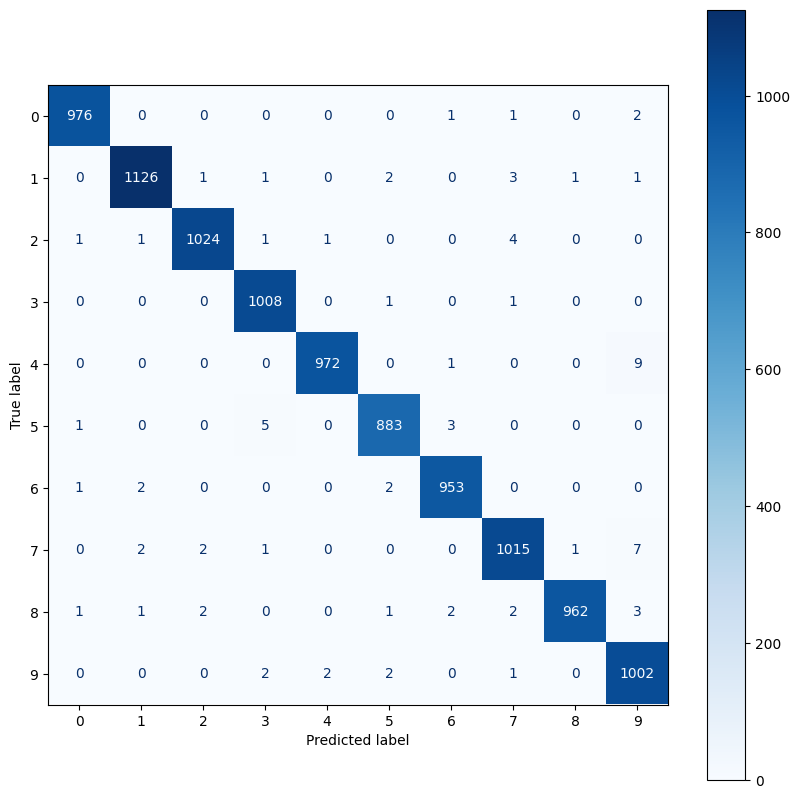

In [40]:
plot_confusion_matrix(labels, pred_labels)

Ce code compare les labels réels avec les labels prédits dans PyTorch et retourne un tenseur booléen indiquant, pour chaque exemple, si la prédiction est correcte (True) ou incorrecte (False).

In [41]:
corrects = torch.eq(labels, pred_labels)

Ce code récupère les exemples mal classés par le modèle dans PyTorch et les trie par niveau de confiance décroissant afin d’identifier les erreurs les plus sûres du modèle.

In [42]:
incorrect_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if not correct:
        incorrect_examples.append((image, label, prob))

incorrect_examples.sort(reverse=True,
                        key=lambda x: torch.max(x[2], dim=0).values)

Cette fonction affiche les **erreurs les plus significatives du modèle** dans PyTorch.

Elle sélectionne un nombre d’exemples incorrects et les organise dans une grille carrée pour la visualisation. Pour chaque image, elle affiche l’image originale ainsi que le label réel et le label prédit par le modèle, avec leurs probabilités associées. Cela permet d’analyser les cas où le modèle s’est trompé avec un haut niveau de confiance et de mieux comprendre ses erreurs.

In [43]:
def plot_most_incorrect(incorrect, n_images):

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 10))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)
        image, true_label, probs = incorrect[i]
        true_prob = probs[true_label]
        incorrect_prob, incorrect_label = torch.max(probs, dim=0)
        ax.imshow(image.view(28, 28).cpu().numpy(), cmap='bone')
        ax.set_title(f'true label: {true_label} ({true_prob:.3f})\n'
                     f'pred label: {incorrect_label} ({incorrect_prob:.3f})')
        ax.axis('off')
    fig.subplots_adjust(hspace=0.5)

Ce code définit le nombre d’exemples à afficher (25) puis appelle la fonction `plot_most_incorrect` pour visualiser les 25 erreurs les plus importantes du modèle dans PyTorch. Cela permet d’analyser qualitativement les mauvaises prédictions les plus confiantes du modèle.

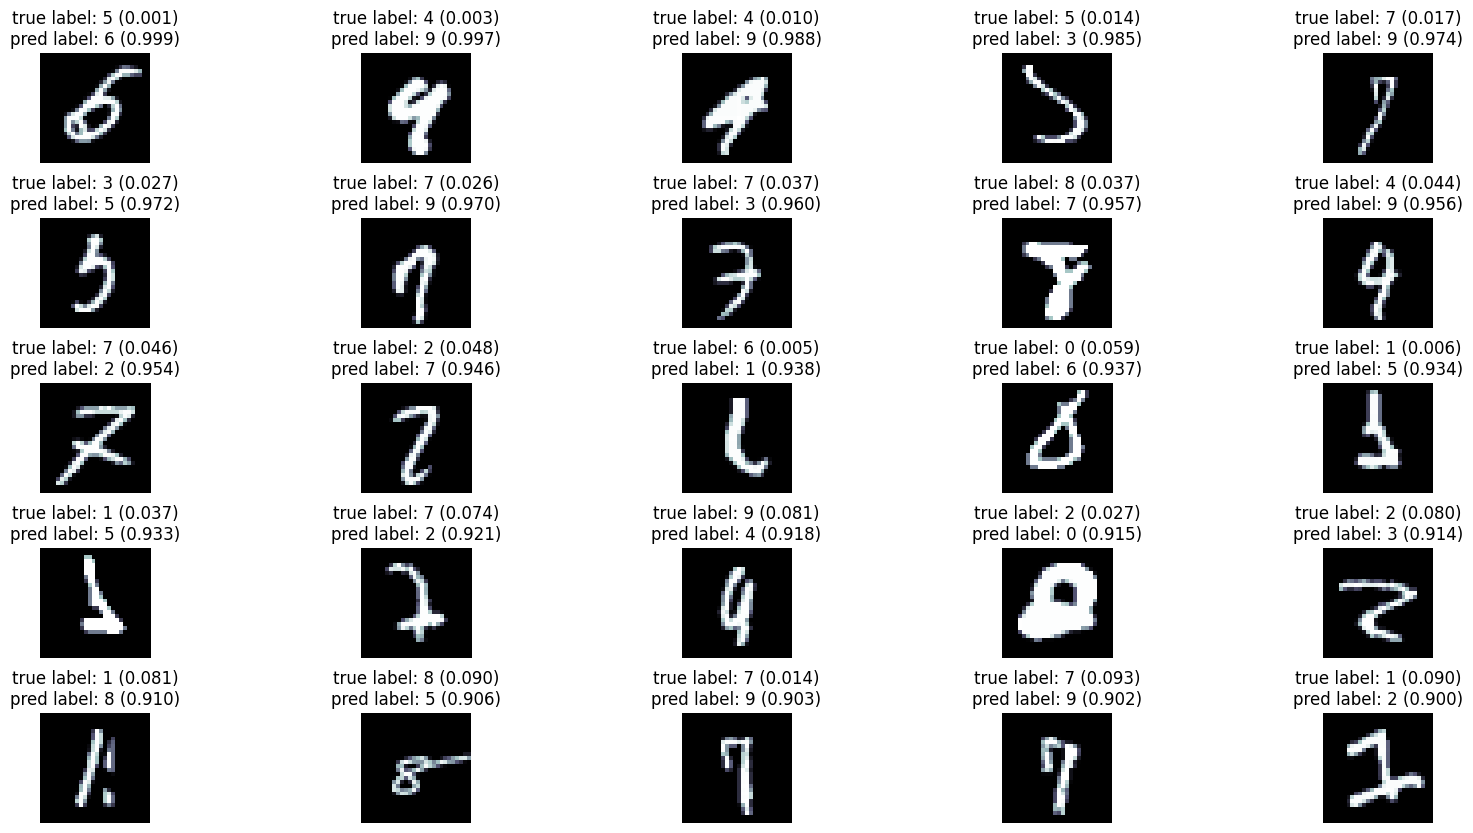

In [44]:
N_IMAGES = 25

plot_most_incorrect(incorrect_examples, N_IMAGES)

Cette fonction extrait les **représentations internes d’un modèle** dans PyTorch.

Elle met le modèle en mode évaluation puis désactive le calcul des gradients pour optimiser les performances. Ensuite, pour chaque batch, elle récupère les sorties finales du modèle ainsi que les représentations intermédiaires (features extraites avant la classification), tout en stockant aussi les labels associés. Ces valeurs sont ensuite concaténées pour obtenir des tenseurs complets sur tout le dataset.

La fonction retourne donc les prédictions finales, les embeddings intermédiaires du réseau et les labels réels, ce qui permet d’analyser et visualiser les features apprises par le modèle.

In [45]:
def get_representations(model, iterator, device):

    model.eval()

    outputs = []
    intermediates = []
    labels = []

    with torch.no_grad():

        for (x, y) in tqdm(iterator):

            x = x.to(device)

            y_pred, h = model(x)

            outputs.append(y_pred.cpu())
            intermediates.append(h.cpu())
            labels.append(y)

    outputs = torch.cat(outputs, dim=0)
    intermediates = torch.cat(intermediates, dim=0)
    labels = torch.cat(labels, dim=0)

    return outputs, intermediates, labels

Ce code récupère les prédictions, les représentations internes et les labels du jeu d’entraînement via `get_representations` dans PyTorch pour analyser les features apprises par le modèle.

In [46]:
outputs, intermediates, labels = get_representations(model,
                                                     train_iterator,
                                                     device)

  0%|          | 0/844 [00:00<?, ?it/s]

Cette fonction applique une **PCA (Analyse en Composantes Principales)** dans Machine Learning pour réduire les données à `n_components` dimensions (ici 2) afin de faciliter leur visualisation.

In [47]:
def get_pca(data, n_components=2):
    pca = decomposition.PCA()
    pca.n_components = n_components
    pca_data = pca.fit_transform(data)
    return pca_data

Cette fonction visualise des données en 2D sous forme de nuage de points.

Elle peut limiter le nombre d’exemples affichés, puis trace les données en utilisant leurs deux premières dimensions comme axes. Chaque point est coloré selon sa classe (labels), ce qui permet de voir comment les différentes classes sont séparées ou regroupées dans l’espace de représentation. Une légende est ajoutée pour identifier les classes.

In [48]:
def plot_representations(data, labels, n_images=None):
    if n_images is not None:
        data = data[:n_images]
        labels = labels[:n_images]
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    scatter = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10')
    handles, labels = scatter.legend_elements()
    ax.legend(handles=handles, labels=labels)

Ce code applique une réduction de dimension PCA dans Machine Learning sur les sorties du modèle afin de les projeter en 2D pour faciliter leur visualisation.

In [49]:
output_pca_data = get_pca(outputs)

Ce code affiche en 2D les sorties du modèle après réduction de dimension (PCA) dans Machine Learning, en colorant chaque point selon sa classe réelle afin de visualiser la séparation des classes.

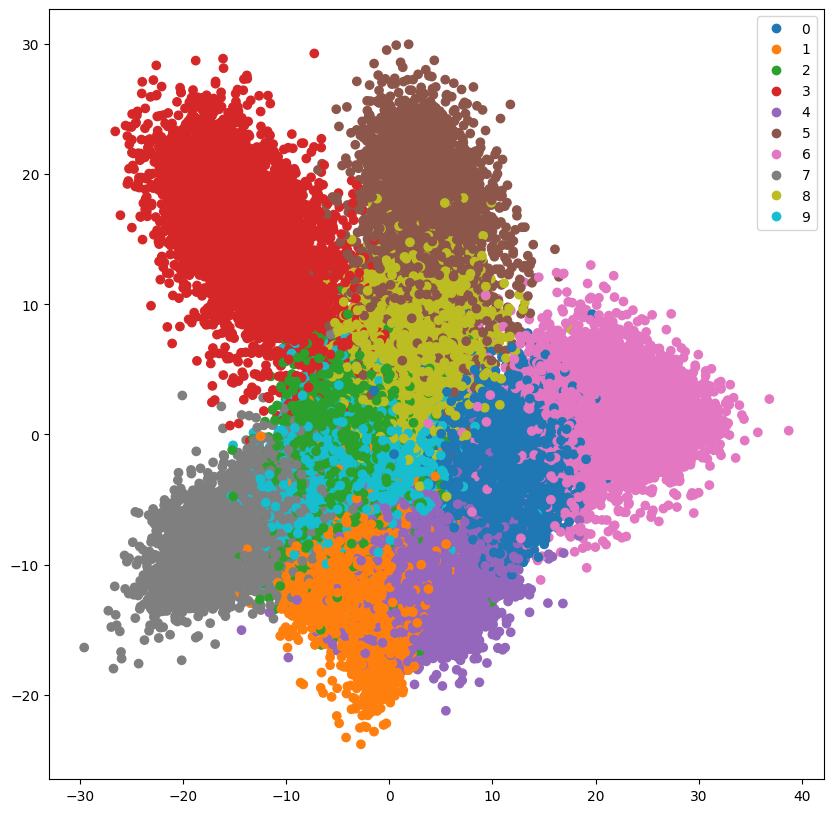

In [50]:
plot_representations(output_pca_data, labels)

Ce code applique une réduction de dimension (PCA) dans Machine Learning sur les représentations intermédiaires du modèle, puis les projette en 2D et les affiche avec leurs labels pour visualiser comment les features internes séparent les classes.

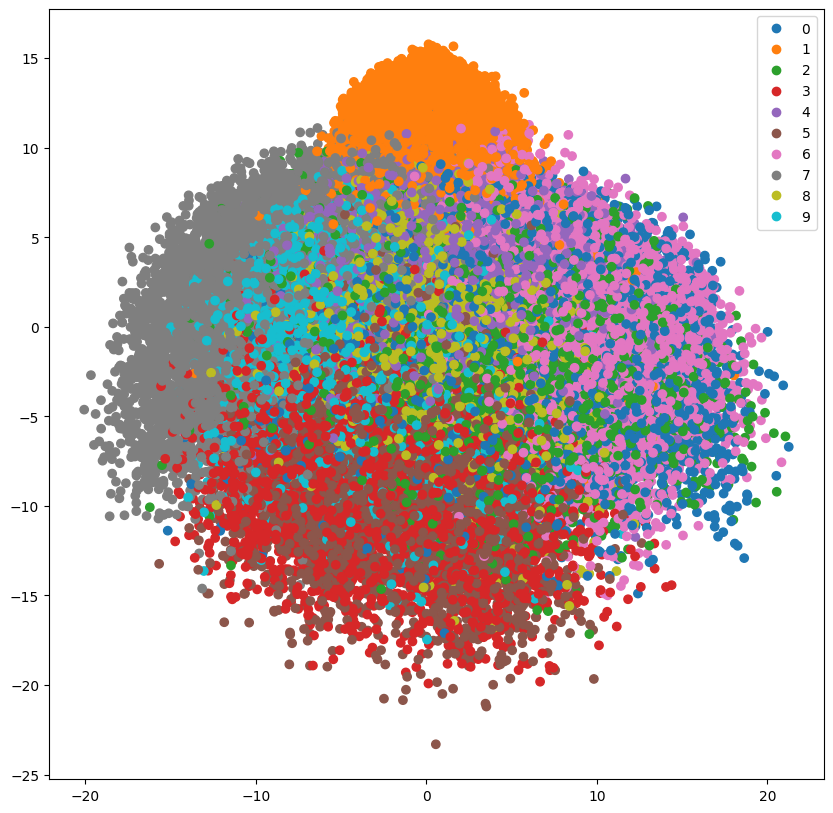

In [51]:
intermediate_pca_data = get_pca(intermediates)
plot_representations(intermediate_pca_data, labels)

Cette fonction applique t-SNE dans Machine Learning pour réduire les données en 2D (ou 3D) afin de les visualiser en conservant les structures locales.

In [52]:
def get_tsne(data, n_components=2, n_images=None):
    if n_images is not None:
        data = data[:n_images]
    tsne = manifold.TSNE(n_components=n_components, random_state=0)
    tsne_data = tsne.fit_transform(data)
    return tsne_data

Ce code applique une réduction de dimension avec t-SNE dans Machine Learning sur les sorties du modèle pour 5 000 exemples, puis visualise les résultats en 2D avec les labels afin d’observer la séparation des classes dans l’espace appris.


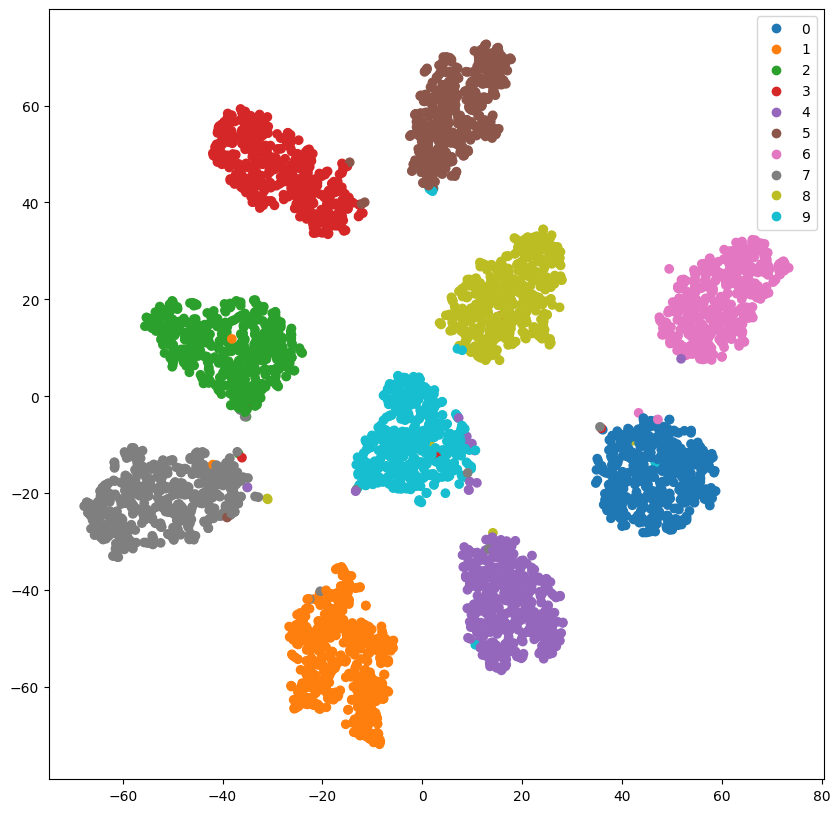

In [53]:
N_IMAGES = 5_000

output_tsne_data = get_tsne(outputs, n_images=N_IMAGES)
plot_representations(output_tsne_data, labels, n_images=N_IMAGES)

Ce code applique une réduction de dimension t-SNE dans Machine Learning sur les représentations intermédiaires du modèle pour 5 000 exemples, puis les affiche en 2D avec leurs labels afin de visualiser comment les features internes structurent et séparent les classes.

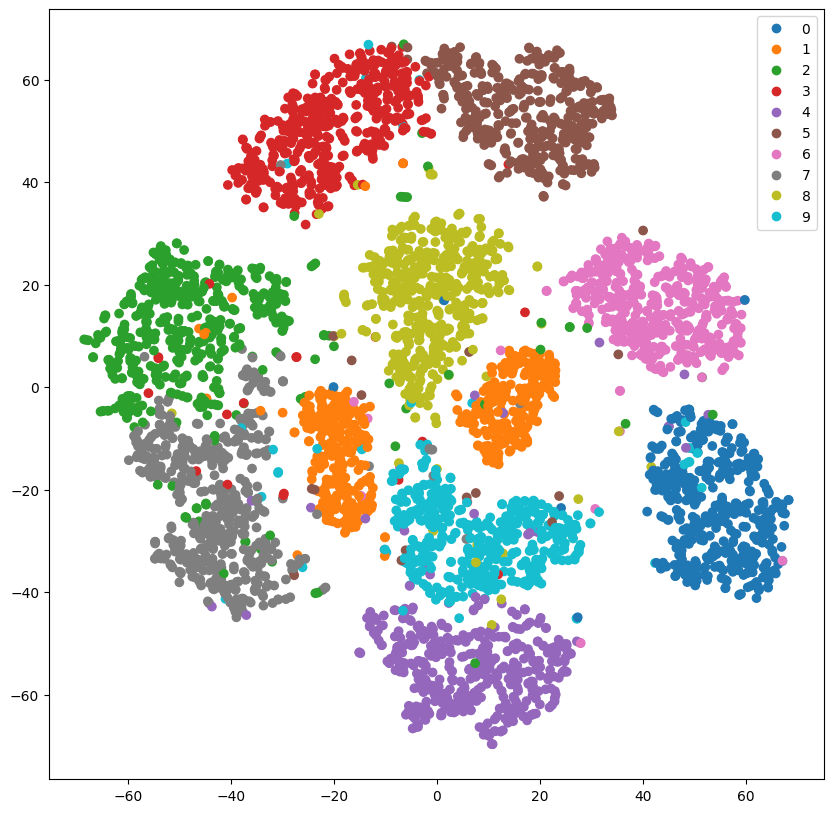

In [54]:
intermediate_tsne_data = get_tsne(intermediates, n_images=N_IMAGES)
plot_representations(intermediate_tsne_data, labels, n_images=N_IMAGES)

Cette fonction génère des images aléatoires et sélectionne celle que le modèle dans PyTorch classe avec la plus forte confiance comme étant le chiffre demandé, puis retourne cette image et sa probabilité.

In [55]:
def imagine_digit(model, digit, device, n_iterations=50_000):

    model.eval()

    best_prob = 0
    best_image = None

    with torch.no_grad():

        for _ in trange(n_iterations):

            x = torch.randn(32, 1, 28, 28).to(device)

            y_pred, _ = model(x)

            preds = F.softmax(y_pred, dim=-1)

            _best_prob, index = torch.max(preds[:, digit], dim=0)

            if _best_prob > best_prob:
                best_prob = _best_prob
                best_image = x[index]

    return best_image, best_prob

Ce code tente de générer une image correspondant au chiffre **3** en utilisant le modèle dans PyTorch. Il appelle la fonction `imagine_digit`, qui recherche une image aléatoire que le modèle classe avec la plus forte probabilité comme étant ce chiffre, puis retourne cette image ainsi que son niveau de confiance.

In [56]:
DIGIT = 3

best_image, best_prob = imagine_digit(model, DIGIT, device)

  0%|          | 0/50000 [00:00<?, ?it/s]

Ce code affiche la probabilité associée à la meilleure image générée pour le chiffre cible dans PyTorch. Il convertit la valeur tensorielle en nombre Python et la multiplie par 100 pour l’exprimer en pourcentage, afin d’évaluer le niveau de confiance du modèle sur cette image.

In [57]:
print(f'Best image probability: {best_prob.item()*100:.2f}%')

Best image probability: 98.70%


Ce code affiche l’image sélectionnée par la fonction `imagine_digit` dans PyTorch. Il enlève les dimensions inutiles du tenseur avec `squeeze`, le transfère sur le CPU, puis le convertit en tableau NumPy pour l’affichage. L’image est ensuite affichée en niveaux de gris avec le colormap `bone`, et les axes sont désactivés pour une visualisation plus propre.

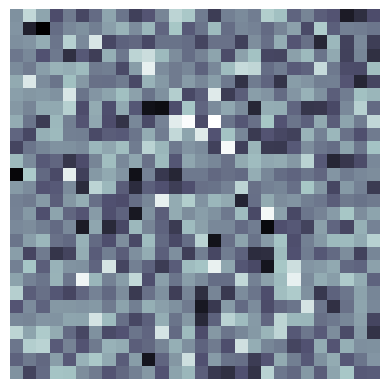

In [58]:
plt.imshow(best_image.squeeze(0).cpu().numpy(), cmap='bone')
plt.axis('off');

Cette fonction applique plusieurs filtres de convolution à un ensemble d’images et visualise le résultat.

Elle commence par convertir la liste d’images en tenseur et s’assure que les images et les filtres sont sur le CPU. Ensuite, elle applique une convolution 2D avec plusieurs filtres en une seule opération, ce qui produit plusieurs images filtrées par entrée.

Enfin, elle affiche pour chaque image : l’image originale et toutes ses versions filtrées, chaque filtre mettant en évidence différents types de caractéristiques (contours, orientations, textures).

In [59]:
def plot_filtered_images(images, filters):

    images = torch.cat([i.unsqueeze(0) for i in images], dim=0).cpu()
    filters = filters.cpu()

    n_images = images.shape[0]
    n_filters = filters.shape[0]

    filtered_images = F.conv2d(images, filters)

    fig = plt.figure(figsize=(20, 10))

    for i in range(n_images):

        ax = fig.add_subplot(n_images, n_filters+1, i+1+(i*n_filters))
        ax.imshow(images[i].squeeze(0), cmap='bone')
        ax.set_title('Original')
        ax.axis('off')

        for j in range(n_filters):
            image = filtered_images[i][j]
            ax = fig.add_subplot(n_images, n_filters+1, i+1+(i*n_filters)+j+1)
            ax.imshow(image.numpy(), cmap='bone')
            ax.set_title(f'Filter {j+1}')
            ax.axis('off')

Ce code sélectionne 5 images du jeu de test, récupère les poids de la première couche convolutionnelle du modèle (qui correspondent aux filtres appris), puis applique ces filtres aux images à l’aide de `plot_filtered_images`.

L’objectif est de visualiser comment les premiers filtres du réseau dans PyTorch réagissent aux images d’entrée et quelles caractéristiques (comme les bords ou textures) ils détectent.

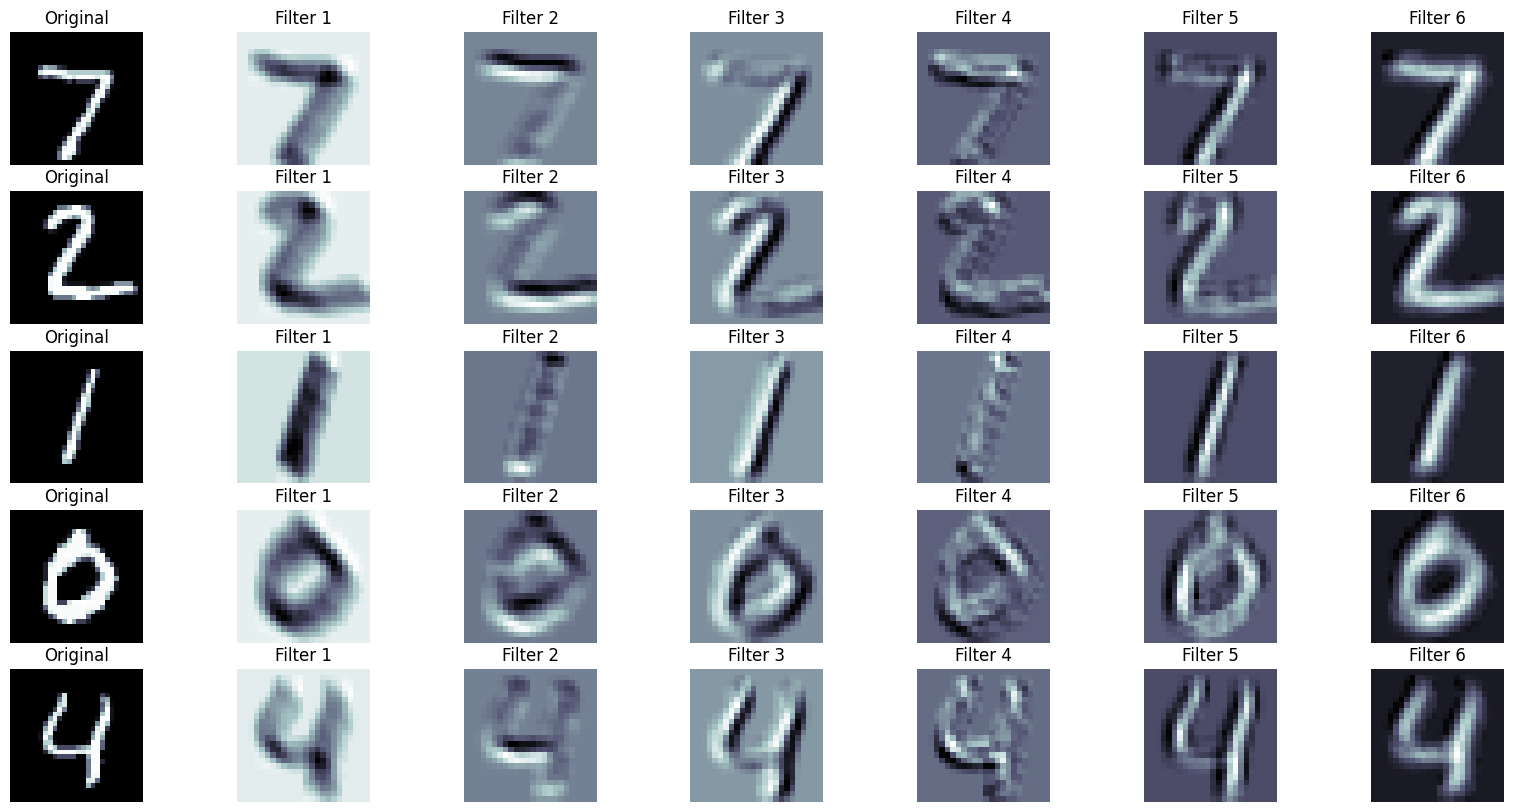

In [60]:
N_IMAGES = 5

images = [image for image, label in [test_data[i] for i in range(N_IMAGES)]]
filters = model.conv1.weight.data

plot_filtered_images(images, filters)

Ce code applique les filtres de la première couche convolutionnelle du modèle dans PyTorch à l’image `best_image`, puis affiche l’image originale et ses versions filtrées pour visualiser les caractéristiques détectées par chaque filtre.

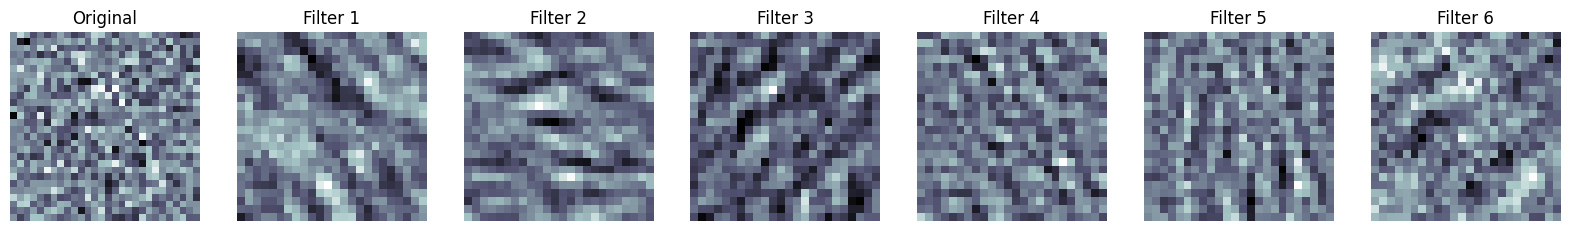

In [61]:
plot_filtered_images([best_image], filters)

Cette fonction affiche les filtres d’une couche convolutionnelle du modèle dans PyTorch.

Elle commence par déplacer les filtres sur le CPU, puis détermine leur nombre. Ensuite, elle les parcourt un par un et les affiche sous forme d’images en niveaux de gris, afin de visualiser ce que chaque filtre a appris (par exemple des motifs de bords, textures ou formes simples).

In [62]:
def plot_filters(filters):

    filters = filters.cpu()

    n_filters = filters.shape[0]

    fig = plt.figure(figsize=(20, 10))

    for i in range(n_filters):

        ax = fig.add_subplot(1, n_filters, i+1)
        ax.imshow(filters[i].squeeze(0), cmap='bone')
        ax.axis('off')

Ce code affiche les filtres de la première couche convolutionnelle du modèle dans PyTorch sous forme d’images, afin de visualiser les motifs appris par chaque filtre.

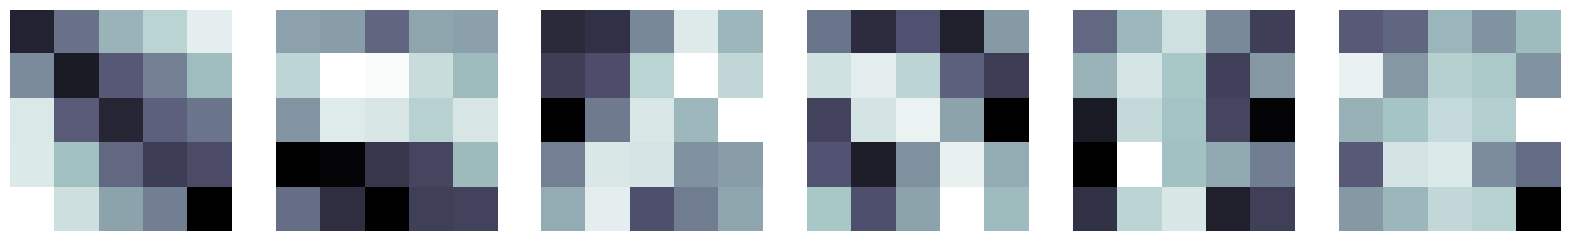

In [63]:
plot_filters(filters)